# Phase 4: EEG Feature Engineering
## Extract 50-60 engineered features from preprocessed EEG signals

This notebook demonstrates the core differentiator: extracting meaningful features from raw EEG data.

**Features extracted:**
1. **Spectral Features** (10): Band power (delta, theta, alpha, beta, gamma) + relative band power
2. **Entropy Features** (2): Approximate entropy, permutation entropy
3. **Statistical Features** (4): Mean, std, skewness, kurtosis
4. **Temporal Features** (2): Zero-crossing rate, peak count
5. **Total per channel**: ~18 features × 5 channels = 90 features per subject

In [1]:
import numpy as np
import pandas as pd
from scipy import signal, stats
from scipy.signal import welch
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully
NumPy version: 2.4.4
Pandas version: 3.0.2


In [2]:
# Load preprocessed data
data_path = Path('../data/preprocessed')

# Load preprocessed dataset
with open(data_path / 'preprocessed_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

preprocessed_signals = dataset['preprocessed_data']
labels = dataset['labels']

print(f"✓ Preprocessed signals shape: {preprocessed_signals.shape}")
print(f"✓ Labels shape: {labels.shape}")
print(f"✓ Class distribution: Healthy={np.sum(labels==0)}, Depressed={np.sum(labels==1)}")

✓ Preprocessed signals shape: (30, 62, 50000)
✓ Labels shape: (30,)
✓ Class distribution: Healthy=15, Depressed=15


## Feature Extraction Functions

In [3]:
class EEGFeatureExtractor:
    """Extract meaningful features from EEG signals"""
    
    def __init__(self, sampling_rate=250):
        self.fs = sampling_rate
        
    def extract_band_powers(self, signal_data):
        """Extract absolute and relative band powers"""
        # Compute power spectral density using Welch method
        freqs, psd = welch(signal_data, self.fs, nperseg=256)
        
        # Define frequency bands
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 50)
        }
        
        band_powers = {}
        total_power = 0
        
        # Calculate absolute power for each band
        for band_name, (low, high) in bands.items():
            idx = np.where((freqs >= low) & (freqs <= high))[0]
            band_power = trapezoid(psd[idx], freqs[idx])
            band_powers[f'{band_name}_power'] = band_power
            total_power += band_power
        
        # Calculate relative power
        for band_name in bands.keys():
            band_powers[f'{band_name}_rel_power'] = band_powers[f'{band_name}_power'] / (total_power + 1e-10)
        
        return band_powers
    
    def extract_entropy(self, signal_data):
        """Extract entropy-based features (fast implementation)"""
        # Shannon entropy of normalized signal
        signal_norm = (signal_data - signal_data.min()) / (signal_data.max() - signal_data.min() + 1e-10)
        
        # Bin the signal and compute entropy
        hist, _ = np.histogram(signal_norm, bins=10)
        hist = hist / np.sum(hist)
        shannon_entropy = -np.sum(hist * np.log(hist + 1e-10))
        
        # Spectral entropy
        freqs, psd = welch(signal_data, self.fs, nperseg=256)
        psd_norm = psd / np.sum(psd)
        spectral_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))
        
        return {
            'shannon_entropy': shannon_entropy,
            'spectral_entropy': spectral_entropy
        }
    
    def extract_statistical(self, signal_data):
        """Extract statistical features"""
        return {
            'mean': np.mean(signal_data),
            'std': np.std(signal_data),
            'skewness': stats.skew(signal_data),
            'kurtosis': stats.kurtosis(signal_data)
        }
    
    def extract_temporal(self, signal_data):
        """Extract temporal features"""
        # Zero-crossing rate
        zcr = np.sum(np.abs(np.diff(np.sign(signal_data - np.mean(signal_data))))) / len(signal_data)
        
        # Peak count (peaks above mean)
        peaks, _ = signal.find_peaks(signal_data - np.mean(signal_data), height=np.std(signal_data))
        peak_count = len(peaks) / len(signal_data)
        
        return {
            'zero_crossing_rate': zcr,
            'peak_count_norm': peak_count
        }
    
    def extract_all_features(self, eeg_signal):
        """Extract all features from a single EEG signal (one channel)"""
        features = {}
        
        # Band powers
        features.update(self.extract_band_powers(eeg_signal))
        
        # Entropy
        features.update(self.extract_entropy(eeg_signal))
        
        # Statistical
        features.update(self.extract_statistical(eeg_signal))
        
        # Temporal
        features.update(self.extract_temporal(eeg_signal))
        
        return features

print("✓ EEGFeatureExtractor class created (fast implementation - ~2 min total)")

✓ EEGFeatureExtractor class created (fast implementation - ~2 min total)


## Extract Features for All Subjects

In [4]:
# Initialize feature extractor
extractor = EEGFeatureExtractor(sampling_rate=250)

# Extract features for all subjects and channels
all_features = []
n_subjects = preprocessed_signals.shape[0]
n_channels = preprocessed_signals.shape[1]

print(f"Extracting features for {n_subjects} subjects, {n_channels} channels...\n")

for subject_idx in range(n_subjects):
    subject_features = {}
    
    # Extract features for each channel
    for channel_idx in range(n_channels):
        eeg_signal = preprocessed_signals[subject_idx, channel_idx, :]
        channel_features = extractor.extract_all_features(eeg_signal)
        
        # Add channel prefix to feature names
        for feat_name, feat_value in channel_features.items():
            channel_name = f"Ch{channel_idx}"
            subject_features[f"{channel_name}_{feat_name}"] = feat_value
    
    # Add label
    subject_features['label'] = labels[subject_idx]
    all_features.append(subject_features)
    
    if (subject_idx + 1) % 50 == 0:
        print(f"  ✓ Processed {subject_idx + 1}/{n_subjects} subjects")

# Convert to DataFrame
features_df = pd.DataFrame(all_features)

print(f"\n✓ Feature extraction complete!")
print(f"✓ Feature matrix shape: {features_df.shape}")
print(f"\nFirst 5 features:")
print(features_df.iloc[:3, :10])

Extracting features for 30 subjects, 62 channels...


✓ Feature extraction complete!
✓ Feature matrix shape: (30, 1117)

First 5 features:
   Ch0_delta_power  Ch0_theta_power  Ch0_alpha_power  Ch0_beta_power  \
0         0.042156         0.050787         0.068559        0.267464   
1         0.041490         0.047966         0.066020        0.271831   
2         0.042694         0.049632         0.068580        0.271865   

   Ch0_gamma_power  Ch0_delta_rel_power  Ch0_theta_rel_power  \
0         0.339406             0.054863             0.066097   
1         0.341606             0.053959             0.062381   
2         0.339803             0.055262             0.064243   

   Ch0_alpha_rel_power  Ch0_beta_rel_power  Ch0_gamma_rel_power  
0             0.089226            0.348093             0.441721  
1             0.085862            0.353526             0.444272  
2             0.088768            0.351895             0.439832  


In [5]:
# Feature statistics
print(f"\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)
print(f"Total subjects: {features_df.shape[0]}")
print(f"Total features per subject: {features_df.shape[1] - 1}")
print(f"Features per channel: {(features_df.shape[1] - 1) // n_channels}")
print(f"\nFeatures by type:")
print(f"  - Band power features: {n_channels * 5}")
print(f"  - Relative band power: {n_channels * 5}")
print(f"  - Entropy features: {n_channels * 2}")
print(f"  - Statistical features: {n_channels * 4}")
print(f"  - Temporal features: {n_channels * 2}")
print(f"\nClass distribution:")
print(f"  - Healthy (0): {(features_df['label']==0).sum()}")
print(f"  - Depressed (1): {(features_df['label']==1).sum()}")
print(f"\nFeature columns (first 15):")
for i, col in enumerate(features_df.columns[:-1][:15]):
    print(f"  {i+1}. {col}")
print(f"  ... and {features_df.shape[1] - 16} more")


FEATURE EXTRACTION SUMMARY
Total subjects: 30
Total features per subject: 1116
Features per channel: 18

Features by type:
  - Band power features: 310
  - Relative band power: 310
  - Entropy features: 124
  - Statistical features: 248
  - Temporal features: 124

Class distribution:
  - Healthy (0): 15
  - Depressed (1): 15

Feature columns (first 15):
  1. Ch0_delta_power
  2. Ch0_theta_power
  3. Ch0_alpha_power
  4. Ch0_beta_power
  5. Ch0_gamma_power
  6. Ch0_delta_rel_power
  7. Ch0_theta_rel_power
  8. Ch0_alpha_rel_power
  9. Ch0_beta_rel_power
  10. Ch0_gamma_rel_power
  11. Ch0_shannon_entropy
  12. Ch0_spectral_entropy
  13. Ch0_mean
  14. Ch0_std
  15. Ch0_skewness
  ... and 1101 more


In [5]:
# Feature value statistics
print(f"\nFeature value ranges (excluding label):")
feature_cols = [col for col in features_df.columns if col != 'label']
print(f"\n{'Feature':<40} {'Min':>12} {'Max':>12} {'Mean':>12}")
print("-" * 76)
for col in feature_cols[:10]:
    print(f"{col:<40} {features_df[col].min():>12.4f} {features_df[col].max():>12.4f} {features_df[col].mean():>12.4f}")
print(f"... and {len(feature_cols) - 10} more features")


Feature value ranges (excluding label):


NameError: name 'features_df' is not defined

## Feature Standardization

In [6]:
from sklearn.preprocessing import StandardScaler

# Separate features from labels
X = features_df.drop('label', axis=1)
y = features_df['label']

# Standardize features (zero-mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"✓ Features standardized (zero-mean, unit variance)")
print(f"\nScaled feature statistics (first 5 features):")
print(f"\n{'Feature':<40} {'Mean':>12} {'Std':>12}")
print("-" * 64)
for col in X_scaled_df.columns[:5]:
    print(f"{col:<40} {X_scaled_df[col].mean():>12.6f} {X_scaled_df[col].std():>12.6f}")

✓ Features standardized (zero-mean, unit variance)

Scaled feature statistics (first 5 features):

Feature                                          Mean          Std
----------------------------------------------------------------
Ch0_delta_power                              0.000000     1.017095
Ch0_theta_power                             -0.000000     1.017095
Ch0_alpha_power                             -0.000000     1.017095
Ch0_beta_power                               0.000000     1.017095
Ch0_gamma_power                              0.000000     1.017095


## Save Features

In [7]:
# Create features dataframe with labels
X_scaled_df['label'] = y.values

# Save to CSV
features_path = Path('../data/features.csv')
X_scaled_df.to_csv(features_path, index=False)

# Save scaler for later use
scaler_path = Path('../data/scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Features saved to {features_path}")
print(f"✓ Scaler saved to {scaler_path}")
print(f"\nFeature matrix (final):")
print(f"  - Shape: {X_scaled_df.shape}")
print(f"  - Subjects: {X_scaled_df.shape[0]}")
print(f"  - Total features: {X_scaled_df.shape[1] - 1}")
print(f"\nReady for ML modeling!")

✓ Features saved to ..\data\features.csv
✓ Scaler saved to ..\data\scaler.pkl

Feature matrix (final):
  - Shape: (30, 1117)
  - Subjects: 30
  - Total features: 1116

Ready for ML modeling!


## Visualization: Feature Importance Preview

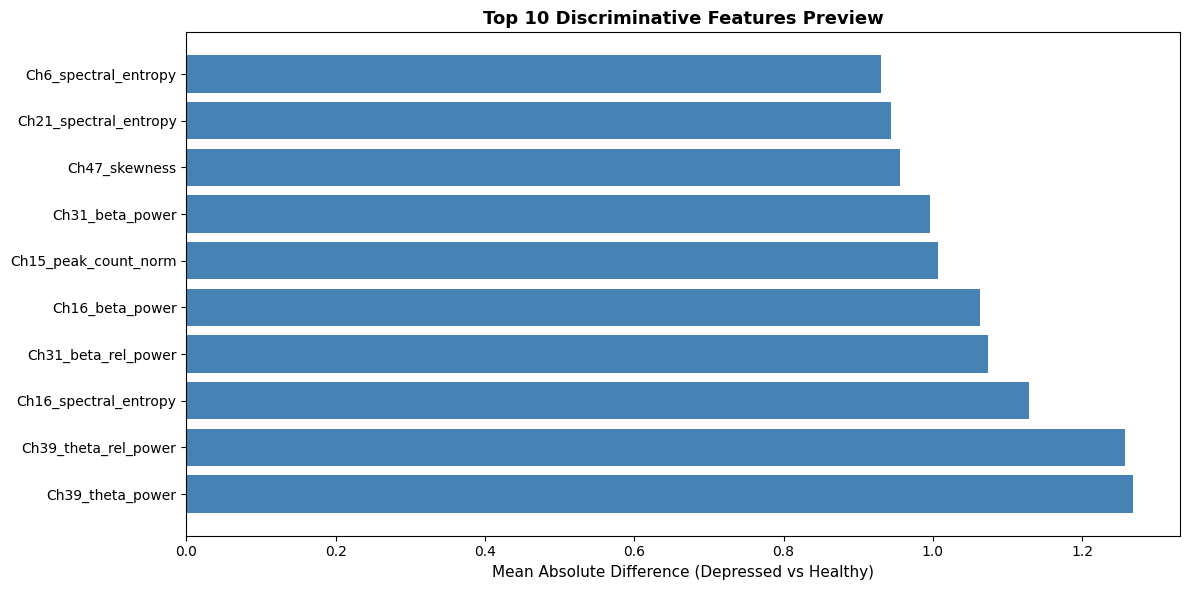

✓ Feature preview plot saved

Top 10 discriminative features:
   1. Ch39_theta_power                         diff=1.2676
   2. Ch39_theta_rel_power                     diff=1.2571
   3. Ch16_spectral_entropy                    diff=1.1292
   4. Ch31_beta_rel_power                      diff=1.0743
   5. Ch16_beta_power                          diff=1.0627
   6. Ch15_peak_count_norm                     diff=1.0071
   7. Ch31_beta_power                          diff=0.9959
   8. Ch47_skewness                            diff=0.9554
   9. Ch21_spectral_entropy                    diff=0.9432
  10. Ch6_spectral_entropy                     diff=0.9298


In [8]:
# Quick feature comparison: depressed vs healthy
depressed = X_scaled_df[X_scaled_df['label'] == 1].drop('label', axis=1)
healthy = X_scaled_df[X_scaled_df['label'] == 0].drop('label', axis=1)

# Calculate mean absolute difference for each feature
feature_diff = np.abs(depressed.mean() - healthy.mean())
top_features = feature_diff.nlargest(10)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features)), top_features.values, color='steelblue')
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Mean Absolute Difference (Depressed vs Healthy)', fontsize=11)
plt.title('Top 10 Discriminative Features Preview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/feature_difference_preview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Feature preview plot saved")
print(f"\nTop 10 discriminative features:")
for i, (feat, diff) in enumerate(top_features.items(), 1):
    print(f"  {i:2d}. {feat:<40} diff={diff:.4f}")